# PCOS Dataset Preprocessing

This notebook focuses on preprocessing the PCOS dataset before machine learning model development. 

The preprocessing stage is important because real-world healthcare datasets often contain:
- missing values
- inconsistent formatting
- noisy data
- outliers
- irrelevant features

Proper preprocessing improves:
- data quality
- model reliability
- prediction accuracy
- interpretability of explainable AI methods such as SHAP and LIME

The steps in this notebook will include:
1. Cleaning column names
2. Removing unnecessary features
3. Handling missing values
4. Investigating and treating outliers
5. Preparing the dataset for machine learning models

In [22]:
import pandas as pd
import numpy as np

# Load the raw PCOS dataset
df = pd.read_csv("../data/raw/PCOS_data.csv")

# Display the first five rows
df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.3,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.9,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.3,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.7,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.1,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [23]:
# Check dataset dimensions
print("Dataset shape:", df.shape)

Dataset shape: (541, 45)


In [24]:
# Clean column names by removing leading and trailing spaces
df.columns = df.columns.str.strip()

# Display cleaned column names
df.columns.tolist()

['Sl. No',
 'Patient File No.',
 'PCOS (Y/N)',
 'Age (yrs)',
 'Weight (Kg)',
 'Height(Cm)',
 'BMI',
 'Blood Group',
 'Pulse rate(bpm)',
 'RR (breaths/min)',
 'Hb(g/dl)',
 'Cycle(R/I)',
 'Cycle length(days)',
 'Marraige Status (Yrs)',
 'Pregnant(Y/N)',
 'No. of abortions',
 'I   beta-HCG(mIU/mL)',
 'II    beta-HCG(mIU/mL)',
 'FSH(mIU/mL)',
 'LH(mIU/mL)',
 'FSH/LH',
 'Hip(inch)',
 'Waist(inch)',
 'Waist:Hip Ratio',
 'TSH (mIU/L)',
 'AMH(ng/mL)',
 'PRL(ng/mL)',
 'Vit D3 (ng/mL)',
 'PRG(ng/mL)',
 'RBS(mg/dl)',
 'Weight gain(Y/N)',
 'hair growth(Y/N)',
 'Skin darkening (Y/N)',
 'Hair loss(Y/N)',
 'Pimples(Y/N)',
 'Fast food (Y/N)',
 'Reg.Exercise(Y/N)',
 'BP _Systolic (mmHg)',
 'BP _Diastolic (mmHg)',
 'Follicle No. (L)',
 'Follicle No. (R)',
 'Avg. F size (L) (mm)',
 'Avg. F size (R) (mm)',
 'Endometrium (mm)',
 'Unnamed: 44']

In [25]:
# Remove unnecessary column with mostly missing values
df.drop(columns=['Unnamed: 44'], inplace=True)

# Check updated dataset shape
print("Updated dataset shape:", df.shape)

Updated dataset shape: (541, 44)


In [26]:
# Check missing values in each column
missing_values = df.isnull().sum()

# Display columns with missing values only
missing_values[missing_values > 0]

Marraige Status (Yrs)    1
Fast food (Y/N)          1
dtype: int64

In [27]:
# Clean column names again
df.columns = df.columns.str.strip()

# Check exact column names with "Marriage"
[col for col in df.columns if "Marriage" in col]

[]

In [28]:
# Show all column names with their index numbers
for i, col in enumerate(df.columns):
    print(i, repr(col))

0 'Sl. No'
1 'Patient File No.'
2 'PCOS (Y/N)'
3 'Age (yrs)'
4 'Weight (Kg)'
5 'Height(Cm)'
6 'BMI'
7 'Blood Group'
8 'Pulse rate(bpm)'
9 'RR (breaths/min)'
10 'Hb(g/dl)'
11 'Cycle(R/I)'
12 'Cycle length(days)'
13 'Marraige Status (Yrs)'
14 'Pregnant(Y/N)'
15 'No. of abortions'
16 'I   beta-HCG(mIU/mL)'
17 'II    beta-HCG(mIU/mL)'
18 'FSH(mIU/mL)'
19 'LH(mIU/mL)'
20 'FSH/LH'
21 'Hip(inch)'
22 'Waist(inch)'
23 'Waist:Hip Ratio'
24 'TSH (mIU/L)'
25 'AMH(ng/mL)'
26 'PRL(ng/mL)'
27 'Vit D3 (ng/mL)'
28 'PRG(ng/mL)'
29 'RBS(mg/dl)'
30 'Weight gain(Y/N)'
31 'hair growth(Y/N)'
32 'Skin darkening (Y/N)'
33 'Hair loss(Y/N)'
34 'Pimples(Y/N)'
35 'Fast food (Y/N)'
36 'Reg.Exercise(Y/N)'
37 'BP _Systolic (mmHg)'
38 'BP _Diastolic (mmHg)'
39 'Follicle No. (L)'
40 'Follicle No. (R)'
41 'Avg. F size (L) (mm)'
42 'Avg. F size (R) (mm)'
43 'Endometrium (mm)'


In [29]:
# Fill missing values using median imputation
# Median was used because medical datasets often contain skewed values and outliers,
# making the median more robust and reliable than the mean.

df['Marraige Status (Yrs)'] = df['Marraige Status (Yrs)'].fillna(
    df['Marraige Status (Yrs)'].median()
)

df['Fast food (Y/N)'] = df['Fast food (Y/N)'].fillna(
    df['Fast food (Y/N)'].median()
)

# Verify that all missing values have been handled
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


## Outlier Investigation

Healthcare datasets often contain extreme biological values or data entry anomalies that can negatively affect machine learning performance.

Outlier analysis is particularly important in PCOS prediction because hormone-related variables such as LH and FSH can contain highly skewed distributions and unrealistic measurements.

Extreme outliers may:
- distort statistical analysis
- bias machine learning models
- reduce generalisation performance
- negatively affect explainability methods such as SHAP and LIME

The following steps investigate hormone-related outliers before deciding whether they should be capped, transformed, or removed.

In [30]:
# Display summary statistics for hormone-related features
hormone_features = ['FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH']

df[hormone_features].describe()

,FSH(mIU/mL),LH(mIU/mL),FSH/LH
count,541.000000,541.000000,541.000000
mean,14.601832,6.469919,6.904917
std,217.022081,86.673255,60.691982
min,0.210000,0.020000,0.000000
25%,3.300000,1.020000,1.420000
50%,4.850000,2.300000,2.170000
75%,6.410000,3.680000,3.960000
max,5052.000000,2018.000000,1372.830000


## Visualising Hormone Outliers

Boxplots were used to identify extreme hormone values in the dataset.

This step is important because unrealistic medical values may negatively affect machine learning model performance and prediction reliability.

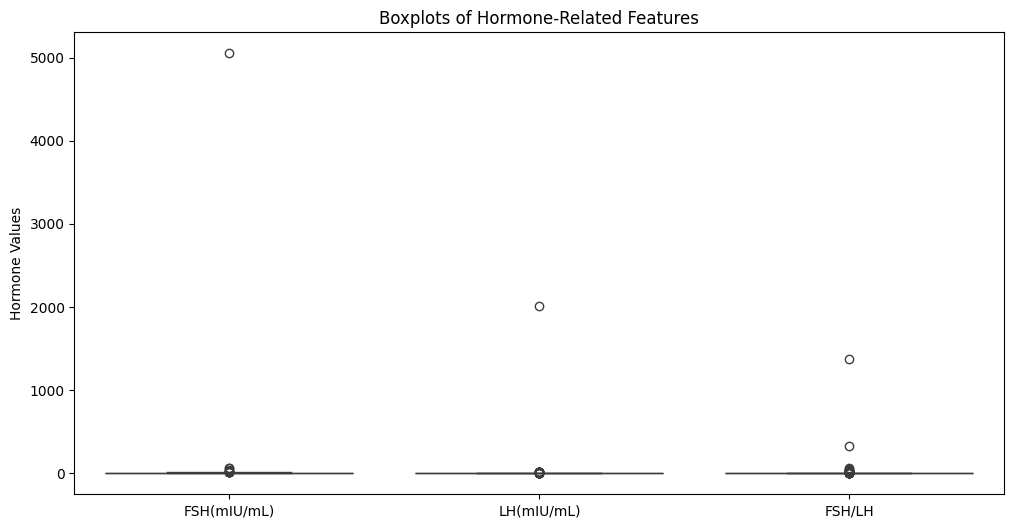

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create boxplots for hormone-related features
plt.figure(figsize=(12, 6))

sns.boxplot(data=df[hormone_features])

plt.title("Boxplots of Hormone-Related Features")
plt.ylabel("Hormone Values")

plt.show()

## Handling Extreme Hormone Outliers

Extreme hormone values were capped using the Interquartile Range (IQR) method after investigating their distributions and identifying biologically unrealistic measurements.

Controlled capping was selected instead of removing rows entirely because:
- the dataset is relatively small
- preserving patient records is important in healthcare datasets
- extreme values may disproportionately affect machine learning models
- outliers can negatively influence explainability methods such as SHAP and LIME

This approach reduces the influence of anomalous values while maintaining the overall dataset structure.

In [32]:
# Function to cap outliers using the IQR method
def cap_outliers(column):
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    # Cap values outside the bounds
    df[column] = np.where(
        df[column] > upper_bound,
        upper_bound,
        np.where(df[column] < lower_bound, lower_bound, df[column])
    )

# Apply controlled capping to hormone-related features
for feature in hormone_features:
    cap_outliers(feature)

print("Hormone outliers capped successfully.")

Hormone outliers capped successfully.


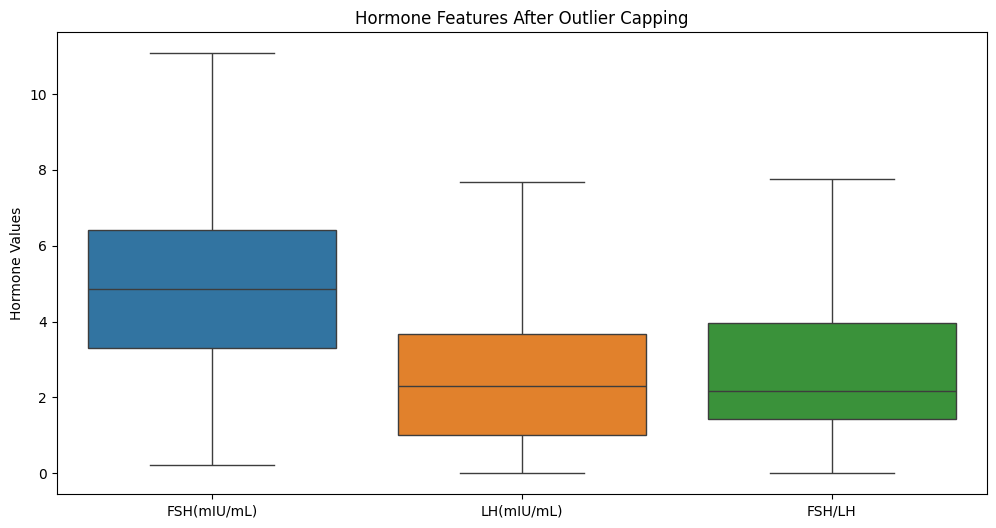

In [33]:
# Visualise hormone features after outlier capping
plt.figure(figsize=(12, 6))

sns.boxplot(data=df[hormone_features])

plt.title("Hormone Features After Outlier Capping")
plt.ylabel("Hormone Values")

plt.show()

In [34]:
# Compare hormone statistics after outlier capping
df[hormone_features].describe()

,FSH(mIU/mL),LH(mIU/mL),FSH/LH
count,541.000000,541.000000,541.000000
mean,4.993200,2.660418,3.013383
std,2.211918,2.018087,2.188556
min,0.210000,0.020000,0.000000
25%,3.300000,1.020000,1.420000
50%,4.850000,2.300000,2.170000
75%,6.410000,3.680000,3.960000
max,11.075000,7.670000,7.770000


## Removing Non-Predictive Features

Identifier-based columns were removed because they do not contain medically meaningful information relevant to PCOS prediction.

Keeping non-predictive identifiers may:
- introduce noise into machine learning models
- reduce generalisation performance
- create misleading patterns during training

Removing these features helps ensure that models learn from clinically relevant variables instead of patient identifiers.

In [35]:
# Remove identifier-related columns
df.drop(columns=['Sl. No', 'Patient File No.'], inplace=True)

# Check updated dataset shape
print("Updated dataset shape:", df.shape)

Updated dataset shape: (541, 42)


In [36]:
# Check first few column names
df.columns[:5]

Index(['PCOS (Y/N)', 'Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI'], dtype='str')

## Separating Features and Target Variable

The dataset was separated into:
- input features (`X`)
- target variable (`y`)

The target variable for prediction was:
- `PCOS (Y/N)`

Separating features from the target variable is an essential machine learning preprocessing step because models must learn relationships between clinical input variables and PCOS diagnosis outcomes.

In [37]:
# Separate features and target variable
X = df.drop(columns=['PCOS (Y/N)'])

y = df['PCOS (Y/N)']

# Display feature and target shapes
print("Feature set shape:", X.shape)
print("Target variable shape:", y.shape)

Feature set shape: (541, 41)
Target variable shape: (541,)


## Saving the Cleaned Dataset

The dataset was saved after completing the initial data cleaning stages of preprocessing.

At this stage, missing values, unnecessary features, and extreme hormone outliers had been handled to improve overall data quality and reliability.

The cleaned dataset will be used in the next preprocessing and machine learning stages, including:
- feature preparation
- train-test splitting
- model training
- evaluation
- explainable AI analysis

In [38]:
# Save cleaned dataset after initial preprocessing
df.to_csv("../data/processed/pcos_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


## Train-Test Split

In [39]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (432, 41)
X_test shape: (109, 41)
y_train shape: (432,)
y_test shape: (109,)


## Feature Scaling

In [40]:
# Check data types
X_train.dtypes

Age (yrs)                   int64
Weight (Kg)               float64
Height(Cm)                float64
BMI                       float64
Blood Group                 int64
Pulse rate(bpm)             int64
RR (breaths/min)            int64
Hb(g/dl)                  float64
Cycle(R/I)                  int64
Cycle length(days)          int64
Marraige Status (Yrs)     float64
Pregnant(Y/N)               int64
No. of abortions            int64
I   beta-HCG(mIU/mL)      float64
II    beta-HCG(mIU/mL)        str
FSH(mIU/mL)               float64
LH(mIU/mL)                float64
FSH/LH                    float64
Hip(inch)                   int64
Waist(inch)                 int64
Waist:Hip Ratio           float64
TSH (mIU/L)               float64
AMH(ng/mL)                    str
PRL(ng/mL)                float64
Vit D3 (ng/mL)            float64
PRG(ng/mL)                float64
RBS(mg/dl)                float64
Weight gain(Y/N)            int64
hair growth(Y/N)            int64
Skin darkening

In [41]:
# Convert object columns to numeric
X_train['II    beta-HCG(mIU/mL)'] = pd.to_numeric(
    X_train['II    beta-HCG(mIU/mL)'],
    errors='coerce'
)

X_test['II    beta-HCG(mIU/mL)'] = pd.to_numeric(
    X_test['II    beta-HCG(mIU/mL)'],
    errors='coerce'
)

X_train['AMH(ng/mL)'] = pd.to_numeric(
    X_train['AMH(ng/mL)'],
    errors='coerce'
)

X_test['AMH(ng/mL)'] = pd.to_numeric(
    X_test['AMH(ng/mL)'],
    errors='coerce'
)

print("Object columns converted to numeric successfully.")

Object columns converted to numeric successfully.


In [42]:
X_train.dtypes

Age (yrs)                   int64
Weight (Kg)               float64
Height(Cm)                float64
BMI                       float64
Blood Group                 int64
Pulse rate(bpm)             int64
RR (breaths/min)            int64
Hb(g/dl)                  float64
Cycle(R/I)                  int64
Cycle length(days)          int64
Marraige Status (Yrs)     float64
Pregnant(Y/N)               int64
No. of abortions            int64
I   beta-HCG(mIU/mL)      float64
II    beta-HCG(mIU/mL)    float64
FSH(mIU/mL)               float64
LH(mIU/mL)                float64
FSH/LH                    float64
Hip(inch)                   int64
Waist(inch)                 int64
Waist:Hip Ratio           float64
TSH (mIU/L)               float64
AMH(ng/mL)                float64
PRL(ng/mL)                float64
Vit D3 (ng/mL)            float64
PRG(ng/mL)                float64
RBS(mg/dl)                float64
Weight gain(Y/N)            int64
hair growth(Y/N)            int64
Skin darkening

In [43]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Scale training and testing features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.
